<div style="margin-bottom: 120px;">
    <div style="float:left;">
        <br/>
        <img src="img/udc.png" width="300"/>
    </div>
</div>

<h1 style="color: #d60e8c; text-align:center;">Clasificación con SVM sin balanceo de datos</h1>

<a name="intro"></a>
<h1 style="color: #d60e8c;">Importamos las librerías</h1>
<hr style="border: 0.5px solid #d60e8c;">

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import time as clocktime

from sklearn import preprocessing
from sklearn.model_selection import train_test_split, ShuffleSplit, KFold, cross_validate, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import GridSearchCV


<a name="dataset"></a>
<h1 style="color: #d60e8c;">Lectura del conjunto de datos</h1>
<hr style="border: 0.5px solid #d60e8c;">

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
path = '/content/drive/MyDrive/Notebooks/puntos_pose/puntos_imgs_sin_v.csv'
#path = 'puntos_imgs_sin_v.csv'

In [4]:
df = pd.read_csv(path)
df.head()

,name,front_left_paw_x,front_left_paw_y,front_left_knee_x,front_left_knee_y,front_left_elbow_x,front_left_elbow_y,rear_left_paw_x,rear_left_paw_y,rear_left_knee_x,...,right_ear_tip_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,withers_x,withers_y,throat_x,throat_y,class
0,n02085620_10074.jpg,0.69520,0.96500,0.66066,0.82400,0.66817,0.67700,0.00000,0.00000,0.0,...,0.06820,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,n02085620_10131.jpg,0.00000,0.00000,0.73502,0.90034,0.73165,0.64646,0.00000,0.00000,0.0,...,0.12733,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,n02085620_1073.jpg,0.00000,0.00000,0.58744,0.96600,0.68792,0.77467,0.00000,0.00000,0.0,...,0.05588,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,n02085620_10976.jpg,0.69876,0.85744,0.63043,0.80096,0.64286,0.67975,0.69876,0.77376,0.0,...,0.24455,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,n02085620_11140.jpg,0.79100,0.56133,0.71000,0.55333,0.62600,0.47867,0.00000,0.00000,0.0,...,0.15180,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [5]:
df.shape

(6125, 50)

In [6]:
df['class'].value_counts()

,count
class,
1,3371
0,1454
2,1300


In [7]:
df['class'] = df['class'].map({0: 0, 1: 1, 2: 0})
df['class'].value_counts()

,count
class,
1,3371
0,2754


In [8]:
df['class'].value_counts()

,count
class,
1,3371
0,2754


<a name="division"></a>
<h1 style="color: #d60e8c;">Selección de atributos de entrada y salida</h1>
<hr style="border: 0.5px solid #d60e8c;">


In [9]:
# 30 seleccionadas
feature_df = df[['front_left_paw_x', 'front_left_paw_y', 'front_left_knee_x',
       'front_left_knee_y', 'front_left_elbow_x', 'front_left_elbow_y',
       'rear_left_paw_x', 'rear_left_paw_y', 'rear_left_knee_x',
       'rear_left_knee_y', 'rear_left_elbow_x', 'rear_left_elbow_y',
       'front_right_paw_x', 'front_right_paw_y', 'front_right_knee_x',
       'front_right_knee_y', 'front_right_elbow_x', 'front_right_elbow_y',
       'rear_right_paw_x', 'rear_right_paw_y', 'rear_right_knee_x',
       'rear_right_knee_y', 'rear_right_elbow_x', 'rear_right_elbow_y',
       'tail_start_x', 'tail_start_y', 'withers_x', 'withers_y', 'throat_x', 'throat_y']]
X_orig = np.asarray(feature_df)

In [10]:
y = np.asarray(df[df.columns[len(df.columns)-1]])

<a name="train_test"></a>
<h1 style="color: #d60e8c;">División en datos de entrenamiento y prueba</h1>
<hr style="border: 0.5px solid #d60e8c;">
El siguiente código, utiliza el 80% del conjunto de datos para entrenar el modelo y el 20% para test.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X_orig, y, test_size=0.2, random_state = 4, stratify=y)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (4900, 30) (4900,)
Test set: (1225, 30) (1225,)


<a name="scale"></a>
<h1 style="color: #d60e8c;">Escalado de los datos</h1>
<hr style="border: 0.5px solid #d60e8c;">

In [12]:
scaler = preprocessing.StandardScaler()
scaler.fit(X_train) # fit realiza los cálculos y los almacena

X_train = scaler.transform(X_train) # aplica los cálculos sobre el conjunto de datos de entrada para escalarlos
X_test = scaler.transform(X_test)

<a name="scale"></a>
<h1 style="color: #d60e8c;">Búsqueda de los mejore hiperparámetros con GridSearchCV</h1>
<hr style="border: 0.5px solid #d60e8c;">


In [13]:
num_splits = 3

In [16]:
parameters = {'kernel': ['linear', 'rbf'],
              'C': [1e-2, 1e-1, 1, 1e1, 1e2],
               'gamma': [1e-2, 1e-1, 1, 1e1, 1e2]
              }

model = svm.SVC(cache_size = 5000)

clf = GridSearchCV(model, parameters, cv=num_splits, n_jobs=-1, refit=False)
clf.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=SVC(cache_size=5000), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10.0, 100.0],
                         'gamma': [0.01, 0.1, 1, 10.0, 100.0],
                         'kernel': ['linear', 'rbf']},
             refit=False)

In [17]:
clf.cv_results_

{'mean_fit_time': array([ 0.32806746,  0.65517855,  0.32857339,  0.63598744,  0.31374796,
         0.64301936,  0.32090863,  0.98802066,  0.32277751,  1.13666161,
         0.36346984,  0.5677019 ,  0.37000291,  0.6212643 ,  0.34109394,
         0.82775474,  0.33020552,  1.030991  ,  0.343503  ,  0.98468781,
         0.55370204,  0.43865585,  0.56243229,  0.45612049,  0.57287343,
         0.76745725,  0.55804594,  1.01423701,  0.54635596,  1.02585912,
         2.14185643,  0.39364624,  2.15796479,  0.502829  ,  2.15996997,
         0.79852025,  2.14106647,  1.02399206,  2.23316717,  1.21311522,
        15.83607411,  0.64968427, 15.56165226,  0.68130787, 15.37003279,
         0.84573483, 14.65695914,  1.01343409, 13.73481393,  1.10326187]),
 'std_fit_time': array([0.00468735, 0.00429451, 0.0071954 , 0.00827157, 0.00913724,
        0.0025682 , 0.01511005, 0.01325097, 0.01858025, 0.1057265 ,
        0.03641153, 0.0096117 , 0.01424913, 0.10488965, 0.00558037,
        0.13936146, 0.010395  ,

In [18]:
clf.cv_results_.keys()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_C', 'param_gamma', 'param_kernel', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score'])

In [19]:
import pandas as pd

results_df = pd.DataFrame(clf.cv_results_)
results_df = results_df.sort_values(by=["rank_test_score"])
results_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,param_kernel,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
41,0.649684,0.070209,0.206077,0.019470,100.0,0.01,rbf,"{'C': 100.0, 'gamma': 0.01, 'kernel': 'rbf'}",0.855569,0.850582,0.854868,0.853673,0.002205,1
31,0.393646,0.004402,0.214130,0.002277,10.0,0.01,rbf,"{'C': 10.0, 'gamma': 0.01, 'kernel': 'rbf'}",0.839657,0.845070,0.840784,0.841837,0.002332,2
33,0.502829,0.005165,0.242415,0.005411,10.0,0.10,rbf,"{'C': 10.0, 'gamma': 0.1, 'kernel': 'rbf'}",0.837209,0.833435,0.830986,0.833877,0.002560,3
43,0.681308,0.008133,0.225305,0.005260,100.0,0.10,rbf,"{'C': 100.0, 'gamma': 0.1, 'kernel': 'rbf'}",0.819461,0.823637,0.815677,0.819592,0.003251,4
23,0.456120,0.005378,0.278074,0.007590,1.0,0.10,rbf,"{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}",0.817625,0.816901,0.818126,0.817551,0.000503,5


In [20]:

best_models = results_df[results_df["rank_test_score"]<=5]
best_models.head()


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,param_kernel,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
41,0.649684,0.070209,0.206077,0.019470,100.0,0.01,rbf,"{'C': 100.0, 'gamma': 0.01, 'kernel': 'rbf'}",0.855569,0.850582,0.854868,0.853673,0.002205,1
31,0.393646,0.004402,0.214130,0.002277,10.0,0.01,rbf,"{'C': 10.0, 'gamma': 0.01, 'kernel': 'rbf'}",0.839657,0.845070,0.840784,0.841837,0.002332,2
33,0.502829,0.005165,0.242415,0.005411,10.0,0.10,rbf,"{'C': 10.0, 'gamma': 0.1, 'kernel': 'rbf'}",0.837209,0.833435,0.830986,0.833877,0.002560,3
43,0.681308,0.008133,0.225305,0.005260,100.0,0.10,rbf,"{'C': 100.0, 'gamma': 0.1, 'kernel': 'rbf'}",0.819461,0.823637,0.815677,0.819592,0.003251,4
23,0.456120,0.005378,0.278074,0.007590,1.0,0.10,rbf,"{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}",0.817625,0.816901,0.818126,0.817551,0.000503,5


In [21]:

best_models[["rank_test_score", "mean_test_score", "std_test_score", "params"]]

,rank_test_score,mean_test_score,std_test_score,params
41,1,0.853673,0.002205,"{'C': 100.0, 'gamma': 0.01, 'kernel': 'rbf'}"
31,2,0.841837,0.002332,"{'C': 10.0, 'gamma': 0.01, 'kernel': 'rbf'}"
33,3,0.833877,0.002560,"{'C': 10.0, 'gamma': 0.1, 'kernel': 'rbf'}"
43,4,0.819592,0.003251,"{'C': 100.0, 'gamma': 0.1, 'kernel': 'rbf'}"
23,5,0.817551,0.000503,"{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}"


<a name="crossval"></a>
<h1 style="color: #d60e8c;">Validación cruzada con los mejores modelos</h1>
<hr style="border: 0.5px solid #d60e8c;">

In [22]:
kf_sh = StratifiedKFold(n_splits=num_splits, shuffle=True, random_state=0) 

In [23]:
test_sets = []
for train_index, test_index in kf_sh.split(X_train, y_train):
    X_train_split, X_test_split = X_train[train_index], X_train[test_index]
    y_train_split, y_test_split = y_train[train_index], y_train[test_index]
    test_sets.append((X_test_split,y_test_split))

In [29]:

results = {}
for model_conf in best_models["params"]:
    model = svm.SVC(cache_size = 5000,
                    kernel=model_conf['kernel'],
                    C=model_conf['C'],
                    gamma=model_conf['gamma']                    
                    )
    res_cv_sh = cross_validate(model,X_train,y_train,cv=kf_sh, return_estimator=True, n_jobs=-1)

    model_name = f'{model_conf['kernel']} - C:{model_conf['C']}, G:{model_conf['gamma']}'
    print(model_name)
    results[model_name] = res_cv_sh


rbf - C:100.0, G:0.01
rbf - C:10.0, G:0.01
rbf - C:10.0, G:0.1
rbf - C:100.0, G:0.1
rbf - C:1, G:0.1


In [31]:

conf_matrix_list = []
labels = ['0','1'] # En el diccionario las claves de las clases son string


print("\n---------------------------------------------")
print(" Exactitud, precisión y sensibilidad media")
print("---------------------------------------------\n")

print("Modelo                         ", end='')    
print("Exactitud    ", end='')
for label in labels:
    print(f"R({label})      ", end='')
for label in labels:
    print(f"P({label})      ", end='')
    
print("\n-------------------------------------------------------------------------------")

for name, res_cv_sh in results.items():
    estimators = res_cv_sh['estimator']   
    conf_matrix = []
    clf_report = []
    for i in range(len(estimators)):
        estimator = estimators[i]
        # Hacemos la predicción con el estimador del split i sobre el conjunto de test del split i
        y_predict = estimator.predict(test_sets[i][0])
        # Valores esperados del conjunto de test del split i
        y_expected = test_sets[i][1]
        # Obtenemos la matriz de confusión y la añadimos a la lista
        conf_matrix.append(confusion_matrix(y_expected, y_predict))
        # Añadimos el classification_report del estimador actual a la lista
        clf_report.append(classification_report(y_expected, y_predict, output_dict=True, zero_division=1))
        #print(classification_report(y_expected, y_predict))

    conf_matrix_list.append((name,conf_matrix))
    
    recall = np.zeros(len(labels))
    precision = np.zeros(len(labels))
    accuracy = []
    for dic in clf_report:
        # Para cada clase, obtiene su valor de exactitud de cada split y la añade a una lista
        for label in labels:
            recall[labels.index(label)] = recall[labels.index(label)] + dic[label]['recall']
            precision[labels.index(label)] = precision[labels.index(label)] + dic[label]['precision']
        accuracy.append(dic['accuracy']) 
    # Para cada clase, calcula la media de la exactitud
    for label in labels:
        recall[labels.index(label)] = recall[labels.index(label)] / len(clf_report)
        precision[labels.index(label)] = precision[labels.index(label)] / len(clf_report)

    accuracy = np.array(accuracy) # Conversión a nparray para usar la función mean
    mean_acc = accuracy.mean()    


    print(f"{name:28}", end='')        
    print(f"{mean_acc:10.3f}", end='')    
    for label in labels:
        print(f"{recall[labels.index(label)]:10.2f}", end='')        
    for label in labels:
        print(f"{precision[labels.index(label)]:10.2f}", end='')                   
    print()



---------------------------------------------
 Exactitud, precisión y sensibilidad media
---------------------------------------------

Modelo                         Exactitud    R(0)      R(1)      P(0)      P(1)      
-------------------------------------------------------------------------------
rbf - C:100.0, G:0.01            0.855      0.87      0.84      0.82      0.89
rbf - C:10.0, G:0.01             0.841      0.85      0.83      0.80      0.87
rbf - C:10.0, G:0.1              0.828      0.83      0.83      0.80      0.86
rbf - C:100.0, G:0.1             0.816      0.81      0.82      0.79      0.84
rbf - C:1, G:0.1                 0.823      0.82      0.83      0.80      0.85


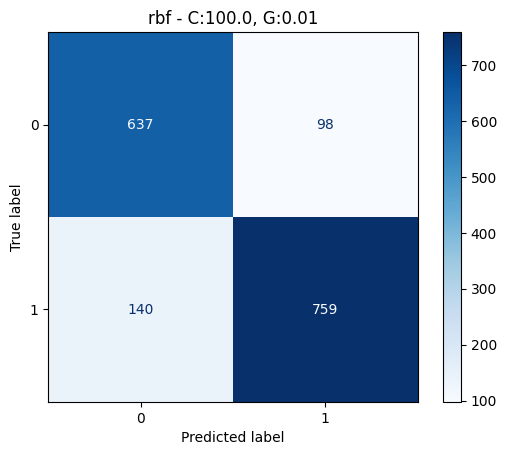

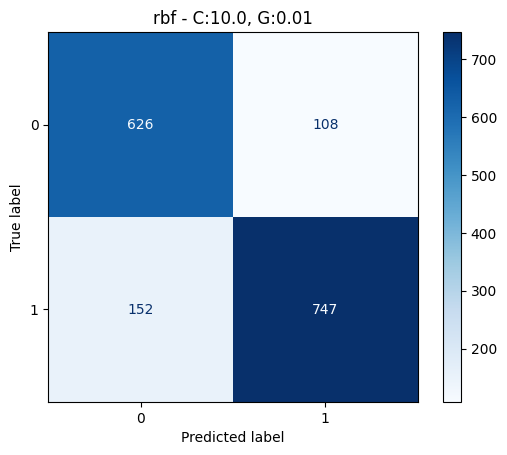

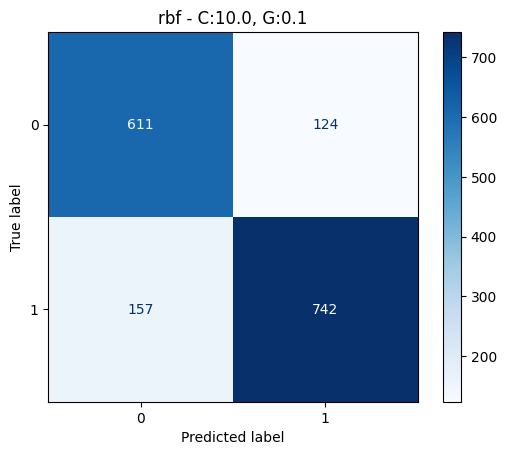

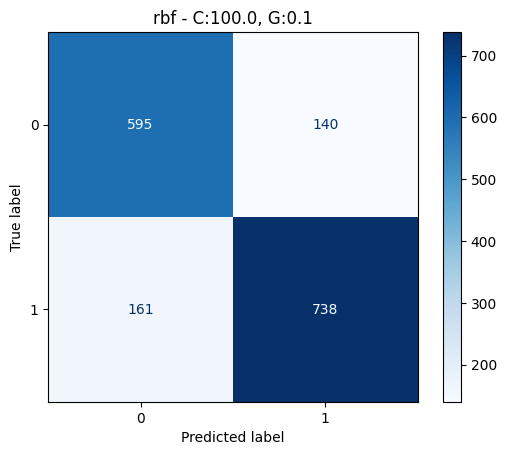

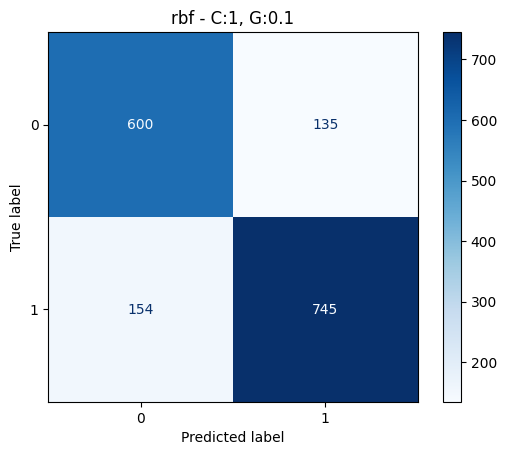

In [32]:

for name, conf_matrix in conf_matrix_list:
    avg_cm = np.zeros(conf_matrix[0].shape, dtype=int)
    for matrix in conf_matrix:
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                avg_cm[i,j] +=  matrix[i,j]
    for i in range(avg_cm.shape[0]):
        for j in range(avg_cm.shape[1]):
            avg_cm[i,j] = int(round(avg_cm[i][j]/len(conf_matrix)))    

    disp = ConfusionMatrixDisplay(confusion_matrix=avg_cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(name)    
    plt.savefig(f'matrix_{name}.png',bbox_inches="tight")
    plt.show()
    plt.close()
    

<br/><br/>
<hr style="border: 0.5px solid #d60e8c;">
<div style="text-align:right;">
MASTER UNIVERSITARIO EN INGENIERÍA INDUSTRIAL
</div>